<h1>02 - Preprocessing & Feature Engineering

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ta
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import joblib

import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [2]:
DATA_PATH = Path("../data/sp500_stocks.csv")
MODELS_DIR = Path("../models")
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df['LogReturn'] = df.groupby("Ticker")["Close"].transform(lambda x: np.log(x / x.shift(1)))
df.head()

,Date,Close,High,Low,Open,Volume,Ticker,LogReturn
0,2005-01-03,0.946491,0.973708,0.936171,0.968773,691992000,AAPL,NaN
1,2005-01-04,0.956211,0.979092,0.941705,0.953968,1096810400,AAPL,0.010218
2,2005-01-05,0.964586,0.975802,0.957856,0.963987,680433600,AAPL,0.008720
3,2005-01-06,0.965334,0.970717,0.947089,0.967128,705555200,AAPL,0.000775
4,2005-01-07,1.035620,1.041304,0.968324,0.972062,2227450400,AAPL,0.070282


<h3>Compute technical indicators using the ta library: RSI(14), MACD(12,26,9), Bollinger Band width(20), ATR(14), OBV, 5-day and 20-day moving average crossover signal.

In [3]:
for col, window in [("SMA_5", 5), ("SMA_20", 20), ("SMA_50", 50), ("SMA_200", 200)]:
    df[col] = df.groupby("Ticker")["Close"].transform(lambda s: s.rolling(window).mean())

df["SMA_5_20_diff"] = (df["SMA_5"] - df["SMA_20"]) / df["SMA_20"]
df["SMA_50_200_diff"] = (df["SMA_50"] - df["SMA_200"]) / df["SMA_200"]

In [4]:
df["RSI"] = df.groupby("Ticker")["Close"].transform(lambda s: ta.momentum.RSIIndicator(s, window=14).rsi())

In [5]:
macd = ta.trend.MACD(df["Close"], window_slow=26, window_fast=12, window_sign=9)
df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()
df["MACD_Histogram"] = macd.macd_diff()

In [6]:
bb = ta.volatility.BollingerBands(df["Close"], window=20, window_dev=2)
df["BB_width"] = (bb.bollinger_hband() - bb.bollinger_lband()) / bb.bollinger_mavg()
df["BB_pct"] = bb.bollinger_pband()

In [7]:
df["ATR_pct"] = ta.volatility.AverageTrueRange(df["High"], df["Low"], df["Close"], window=14).average_true_range() / df["Close"]

In [8]:
obv = ta.volume.OnBalanceVolumeIndicator(df["Close"], df["Volume"]).on_balance_volume()
df["OBV_z"] = (obv - obv.rolling(window=20).mean()) / obv.rolling(window=20).std()

In [9]:
df[df["Ticker"] == df["Ticker"].iloc[0]].tail()

,Date,Close,High,Low,Open,Volume,Ticker,LogReturn,SMA_5,SMA_20,...,SMA_5_20_diff,SMA_50_200_diff,RSI,MACD,MACD_Signal,MACD_Histogram,BB_width,BB_pct,ATR_pct,OBV_z
5277,2025-12-23,271.620667,271.760301,268.828279,270.104803,29642000,AAPL,0.005117,271.467090,276.557220,...,-0.018405,0.176121,47.029036,0.369715,1.726079,-1.356364,0.058676,0.195786,0.017400,1.264416
5278,2025-12-24,273.066711,274.682309,271.461097,271.600701,17910600,AAPL,0.005310,271.860016,276.399649,...,-0.016424,0.177032,50.012074,0.301930,1.441249,-1.139319,0.059732,0.298126,0.016914,1.356472
5279,2025-12-26,272.657837,274.622490,272.119294,273.415784,21521800,AAPL,-0.001498,272.101361,276.192712,...,-0.014813,0.177681,49.168925,0.212766,1.195553,-0.982787,0.060906,0.289863,0.016385,0.983678
5280,2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,AAPL,0.001316,272.119305,275.938904,...,-0.013842,0.178329,49.966601,0.169124,0.990267,-0.821143,0.061407,0.327554,0.015719,1.195387
5281,2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600,AAPL,-0.002487,272.540155,275.439264,...,-0.010525,0.178611,48.420900,0.078903,0.807994,-0.729091,0.058631,0.308006,0.015104,0.900029


In [10]:
vix_path = Path("../data/vix.csv")
vix_raw = pd.read_csv(vix_path)
vix_raw["Date"] = pd.to_datetime(vix_raw["Date"])

vix = vix_raw[["Date", "Close"]].rename(columns={"Close": "VIX_Close"})

df = df.merge(vix, on="Date", how="left")
df["VIX_Close"] = df.groupby("Ticker")["VIX_Close"].ffill()

<h3>Create target variables: (a) next-day log return (regression target), (b) 5-day return direction: 1 if positive, 0 if negative (classification target).

In [11]:
def add_targets(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["target_next_day_logreturn"] = df["LogReturn"].shift(-1)
    fwd_5d_logreturn = np.log(df["Close"].shift(-5) / df["Close"])
    out["target_5d_logreturn"] = fwd_5d_logreturn
    out["target_5d_direction"] = (fwd_5d_logreturn > 0).astype(int)
    return out

targets = df.groupby("Ticker", group_keys=False).apply(add_targets)
df = pd.concat([df, targets], axis=1)
df[["Date", "Ticker", "LogReturn", "target_next_day_logreturn",  "target_5d_direction"]].tail()

,Date,Ticker,LogReturn,target_next_day_logreturn,target_5d_direction
259068,2025-12-23,XOM,0.010692,-0.001676,0
259069,2025-12-24,XOM,-0.001676,-0.000923,0
259070,2025-12-26,XOM,-0.000923,0.011851,0
259071,2025-12-29,XOM,0.011851,0.003809,0
259072,2025-12-30,XOM,0.003809,NaN,0


<h3>Handle NaN values created by indicator calculations (e.g., first 14 rows for RSI). Drop or forward-fill as appropriate.

In [12]:
FEATURE_COLS = [
    "LogReturn",
    "SMA_5_20_diff", "SMA_50_200_diff",
    "RSI",
    "MACD", "MACD_Signal", "MACD_Histogram",
    "BB_width", "BB_pct",
    "ATR_pct",
    "OBV_z",
    "VIX_Close"
]
TARGET_COLS = ["target_next_day_logreturn", "target_5d_logreturn", "target_5d_direction"]

rows_before = len(df)
df_clean = df.dropna(subset=FEATURE_COLS + ["target_next_day_logreturn"]).reset_index(drop=True)
rows_after = len(df_clean)
print(f"Dropped {rows_before - rows_after} rows ({(rows_before - rows_after) / rows_before:.1%}) "
      f"to indicator warm-up / target horizon NaNs")
print(f"{rows_after} modeling rows remain across {df_clean['Ticker'].nunique()} tickers")

Dropped 10000 rows (3.9%) to indicator warm-up / target horizon NaNs
249073 modeling rows remain across 50 tickers


<h3>Split data temporally: training = first 70%, validation = next 15%, test = last 15%. NEVER shuffle time-series data across splits. Document why random splits are invalid for financial data.

In [13]:
unique_dates = np.sort(df_clean["Date"].unique())
train_end = unique_dates[int(len(unique_dates) * 0.7)]
val_end = unique_dates[int(len(unique_dates) * 0.85)]

train_df = df_clean[df_clean["Date"] <= train_end].reset_index(drop=True)
val_df = df_clean[(df_clean["Date"] >= train_end) & (df_clean["Date"] < val_end)].reset_index(drop=True)
test_df = df_clean[df_clean["Date"] >= val_end].reset_index(drop=True)

print(f"Train: {len(train_df):>6} rows | {train_df['Date'].min().date()} -> {train_df['Date'].max().date()}")
print(f"Val:   {len(val_df):>6} rows | {val_df['Date'].min().date()} -> {val_df['Date'].max().date()}")
print(f"Test:  {len(test_df):>6} rows | {test_df['Date'].min().date()} -> {test_df['Date'].max().date()}")

Train: 172873 rows | 2005-10-17 -> 2019-12-04
Val:    38100 rows | 2019-12-04 -> 2022-12-12
Test:   38150 rows | 2022-12-13 -> 2025-12-29


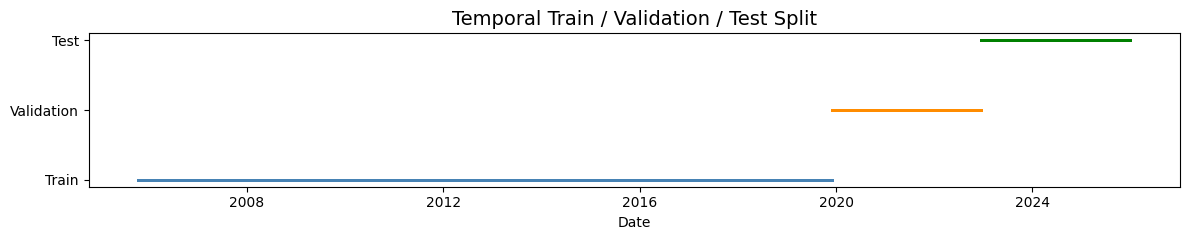

In [14]:
fig, ax = plt.subplots(figsize=(12, 2.5))
for name, d, color in [("Train", train_df, "steelblue"), ("Validation", val_df, "darkorange"), ("Test", test_df, "Green")]:
    ax.scatter(d["Date"], [name] * len(d), s=1, color=color)
ax.set_title("Temporal Train / Validation / Test Split", fontsize=14)
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

<h3>Normalize all features using StandardScaler fit on training data only. Apply to validation and test using the training scaler.

In [15]:
scaler = StandardScaler()
scaler.fit(train_df[FEATURE_COLS])

for split_df in (train_df, val_df, test_df):
    split_df[FEATURE_COLS] = scaler.transform(split_df[FEATURE_COLS])

joblib.dump(scaler, MODELS_DIR / "feature_scaler.joblib")
joblib.dump(FEATURE_COLS, MODELS_DIR / "feature_cols.joblib")

train_df[FEATURE_COLS].describe().loc[["mean", "std"]]

,LogReturn,SMA_5_20_diff,SMA_50_200_diff,RSI,MACD,MACD_Signal,MACD_Histogram,BB_width,BB_pct,ATR_pct,OBV_z,VIX_Close
mean,3.041549e-18,2.038660e-17,1.972896e-17,2.916598e-16,-7.891585e-18,5.261057e-18,-1.393358e-17,9.469903e-17,-7.760059e-17,3.682740e-17,-1.446791e-17,-3.419687e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00


In [16]:
train_df.to_csv(PROCESSED_DIR / "train.csv", index=False)
val_df.to_csv(PROCESSED_DIR / "val.csv", index=False)
test_df.to_csv(PROCESSED_DIR / "test.csv", index=False)
print("Saved processed splits to ", PROCESSED_DIR.resolve())

Saved processed splits to  C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ml_2\data\processed


<h3>Create a PyTorch Dataset class that returns (features, target) pairs. Create DataLoaders with batch_size=64.


In [17]:
class CrossSectionalDataset(Dataset):
    def __init__(self, df: pd.DataFrame, feature_cols: list[str], target_cols: list[str]):
        self.x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
        self.y = torch.tensor(df[target_cols].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx: int):
        return self.x[idx], self.y[idx]

TARGET_COL = "target_next_day_logreturn"

train_ds = CrossSectionalDataset(train_df, FEATURE_COLS, TARGET_COL)
val_ds = CrossSectionalDataset(val_df, FEATURE_COLS, TARGET_COL)
test_ds = CrossSectionalDataset(test_df, FEATURE_COLS, TARGET_COL)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

xb, yb = next(iter(train_loader))
print(f"Cross-sectional batch: X={tuple(xb.shape)}, y={tuple(yb.shape)}")

Cross-sectional batch: X=(64, 12), y=(64, 1)


In [18]:
SEQ_LEN = 60

class SequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, feature_cols: list[str], target_cols: str,
                 seq_len: int = SEQ_LEN, ticker_col: str = "Ticker", date_col: str = "Date"):
        self.seq_len = seq_len
        self.samples = []

        for _, group in df.sort_values(date_col).groupby(ticker_col):
            features = group[feature_cols].to_numpy(dtype=np.float32)
            targets = group[target_cols].to_numpy(dtype=np.float32)
            for i in range(len(group) - seq_len):
                target = targets[i + seq_len - 1]
                if not np.isnan(target):
                    self.samples.append((features[i:i + seq_len], target))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        window, target = self.samples[idx]
        return torch.from_numpy(window), torch.tensor(target, dtype=torch.float32)

train_seq_ds = SequenceDataset(train_df, FEATURE_COLS, TARGET_COL)
val_seq_ds = SequenceDataset(val_df, FEATURE_COLS, TARGET_COL)
test_seq_ds = SequenceDataset(test_df, FEATURE_COLS, TARGET_COL)

train_seq_loader = DataLoader(train_seq_ds, batch_size=64, shuffle=True)
val_seq_loader = DataLoader(val_seq_ds, batch_size=64, shuffle=False)
test_seq_loader = DataLoader(test_seq_ds, batch_size=64, shuffle=False)

xb, yb = next(iter(train_seq_loader))
print(f"Sequence batch: X={tuple(xb.shape)} (batch, seq_len, features), y={tuple(yb.shape)}")
print(f"Train/val/test sequence samples: {len(train_seq_ds)}, {len(val_seq_ds)}, {len(test_seq_ds)}")

Sequence batch: X=(64, 60, 12) (batch, seq_len, features), y=(64,)
Train/val/test sequence samples: 169873, 35100, 35150


<h3>Save preprocessed tensors to data/processed/ for use in subsequent notebooks.


In [19]:
def save_cross_sectional_tensors(ds, name):
    loader = DataLoader(ds, batch_size=len(ds), shuffle=False)
    X, y = next(iter(loader))
    torch.save({"X": X, "y": y}, PROCESSED_DIR / f"{name}_cross_sectional.pt")

save_cross_sectional_tensors(train_ds, "train")
save_cross_sectional_tensors(val_ds, "val")
save_cross_sectional_tensors(test_ds, "test")


def save_sequence_tensors(ds, name):
    X = np.stack([window for window, _ in ds.samples])
    y = np.array([[target] for _, target in ds.samples], dtype=np.float32)
    torch.save({"X": torch.from_numpy(X), "y": torch.from_numpy(y)}, PROCESSED_DIR / f"{name}_sequence.pt")

save_sequence_tensors(train_seq_ds, "train")
save_sequence_tensors(val_seq_ds, "val")
save_sequence_tensors(test_seq_ds, "test")

print("Saved tensors to", PROCESSED_DIR.resolve())

Saved tensors to C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ml_2\data\processed
